In [28]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt
Xset.parallel.steppar = 10 # number of threads for steppar


# GOAL: to fit spectra in a window around the line. Use XSpec to fit

I only use 1 power-law+ gaussians. The goal is to check if this works for E>2 keV

Here I load the data 

In [29]:

AllData.clear()
path="/home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/"
#filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
#fileRMF=path+"srctoolout_120_RMF_00001.fits"
#fileARF=path+"srctoolout_120_ARF_00001.fits"
filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
fileIBLineTM1="/home/jortecal/GitHub/eRosita/IBLines/LinesTM1.txt"
#
filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
fileIBLineTM2="/home/j6 #6ortecal/GitHub/eRosita/IBLines/LinesTM2.txt"
#
filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
fileIBLineTM3="/home/jortecal/GitHub/eRosita/IBLines/LinesTM3.txt"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
fileIBLineTM4="/home/jortecal/GitHub/eRosita/IBLines/LinesTM4.txt"
#
filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
fileIBLineTM5="/home/jortecal/GitHub/eRosita/IBLines/LinesTM5.txt"
#
filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
fileIBLineTM6="/home/jortecal/GitHub/eRosita/IBLines/LinesTM6.txt"
#
filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
fileIBLineTM7="/home/jortecal/GitHub/eRosita/IBLines/LinesTM7.txt"
#
#Put here the TM you want to use 
#
telescope = "TM7" 

# Define telescope file mappings
telescope_files = {
    "TM1": (filespectrumTM1, fileRMFTM1, fileARFTM1, fileIBLineTM1),
    "TM2": (filespectrumTM2, fileRMFTM2, fileARFTM2, fileIBLineTM2),
    "TM3": (filespectrumTM3, fileRMFTM3, fileARFTM3, fileIBLineTM3),
    "TM4": (filespectrumTM4, fileRMFTM4, fileARFTM4, fileIBLineTM4),
    "TM5": (filespectrumTM5, fileRMFTM5, fileARFTM5, fileIBLineTM5),
    "TM6": (filespectrumTM6, fileRMFTM6, fileARFTM6, fileIBLineTM6),
    "TM7": (filespectrumTM7, fileRMFTM7, fileARFTM7, fileIBLineTM7),
    "ALL": ([filespectrumTM1, filespectrumTM2, filespectrumTM3, filespectrumTM4, filespectrumTM5, filespectrumTM6, filespectrumTM7],
            [fileRMFTM1, fileRMFTM2, fileRMFTM3, fileRMFTM4, fileRMFTM5, fileRMFTM6, fileRMFTM7],
            [fileARFTM1, fileARFTM2, fileARFTM3, fileARFTM4, fileARFTM5, fileARFTM6, fileARFTM7],
            [fileIBLineTM1, fileIBLineTM2, fileIBLineTM3, fileIBLineTM4, fileIBLineTM5, fileIBLineTM6, fileIBLineTM7]),
    "ALL_CLEAN": ([filespectrumTM1, filespectrumTM2, filespectrumTM3, filespectrumTM4, filespectrumTM6],
    [fileRMFTM1, fileRMFTM2, fileRMFTM3, fileRMFTM4, fileRMFTM6],
    [fileARFTM1, fileARFTM2, fileARFTM3, fileARFTM4, fileARFTM6],
    [fileIBLineTM1, fileIBLineTM2, fileIBLineTM3, fileIBLineTM4, fileIBLineTM6])
}

# Set the file arrays based on telescope selection
if telescope in telescope_files:
    if telescope == "ALL":
        vfilespectrum, vfileRMF, vfileARF, vfileIBLine = telescope_files[telescope]
    else:
        spectrum_file, rmf_file, arf_file, ibline_file = telescope_files[telescope]
        vfilespectrum = [spectrum_file]
        vfileRMF = [rmf_file]
        vfileARF = [arf_file]
        vfileIBLine = [ibline_file]
    print(f"Using telescope: {telescope}")
    print(f"Number of telescopes: {len(vfilespectrum)}")
else:
    print(f"Error: Unknown telescope '{telescope}'. Valid options: TM1, TM2, TM3, TM4, TM5, TM6, TM7, ALL_CLEAN")
    sys.exit(1)
# vfilespectrum = [filespectrumTM4]
# vfileRMF = [fileRMFTM4]
# vfileARF = [fileARFTM4]
#
#LOAD DATA
#

#
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).multiresponse[0] = vfileRMF[plot_grp]
    AllData(plot_grp+1).multiresponse[0].arf = vfileARF[plot_grp]
    AllData(plot_grp+1).multiresponse[1] = vfileRMF[plot_grp] # RMF only for src2

AllData.show()

Using telescope: TM7
Number of telescopes: 1


Error: cannot read response file srctoolout_720_RMF_00001.fits


NOW LOAD the Sigma of EROSITA. At the moment I take the FWHM from https://erosita.mpe.mpg.de/edr/eROSITATechnical/calibration.html
Computing \sigma=FWHM/2.355 I find that \sigma ranges from [33,72] eV and E/sigma = [34,139] for E ranging from 1 to 10 keV. 
This is >> sigmav = c/v = 1360 for v=220 km/s.
Larger than intrinsic/Doppler width of astro lines???

In [30]:
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/Energy_width.txt",delimiter=",")
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
vsigma = vFWHM/(2.355)

Fix the energy of the DM line and select data

In [31]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 10

Eline = 7.483 #6.266

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
# Emin= 6.0
# Emax= 9.0
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
# Emin= 1.0
# Emax= 3.0
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)


Plot.commands = ()
Plot.addCommand("area")
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))


Eline  7.483  sigma  0.06122332974935731
Emin  7.176883351253213  Emax  7.789116648746786
**-7.1769,,7.7891-**
Plot command list is now empty
NEbins  44
 Syntax: Ajust ON|OFF wlist
***************
Selected values  7.195790529251099   7.776113510131836  Nbins  44
***************
Min Max counts  253   376


In [32]:
print("sigma ",sigma)
print("DeltaE ",vedeltas[0]*2)
print("Sigma/DeltaE ",sigma/(vedeltas[0]*2))

sigma  0.06122332974935731
DeltaE  [0.01322222 0.01323366 0.01324606 0.0132575  0.0132699  0.01328039
 0.01329327 0.01330662 0.01331758 0.01333046 0.01334286 0.01335526
 0.01336718 0.01337957 0.01339293 0.01340532 0.01341915 0.0134306
 0.01344442 0.01345682 0.0134697  0.013484   0.0134964  0.01350975
 0.0135231  0.01353741 0.01355028 0.01356411 0.01357746 0.01359034
 0.01360559 0.01361942 0.01363325 0.01364756 0.01366234 0.01367569
 0.01369047 0.01370382 0.01371956 0.01373386 0.0137496  0.0137639
 0.01377773 0.01379395]
Sigma/DeltaE  [4.6303375  4.62633331 4.62200326 4.61801347 4.61369896 4.61005452
 4.60558966 4.60096855 4.59717958 4.59273961 4.58847218 4.58421267
 4.58012444 4.57588041 4.5713187  4.56709097 4.56238464 4.55849707
 4.55380842 4.549613   4.54526439 4.54044234 4.5362715  4.53178838
 4.52731412 4.52253006 4.51823304 4.51362682 4.50918833 4.50491661
 4.49986431 4.49529544 4.49073584 4.48602874 4.48117508 4.47680015
 4.47196644 4.46760947 4.46248535 4.45783725 4.45273551 4.

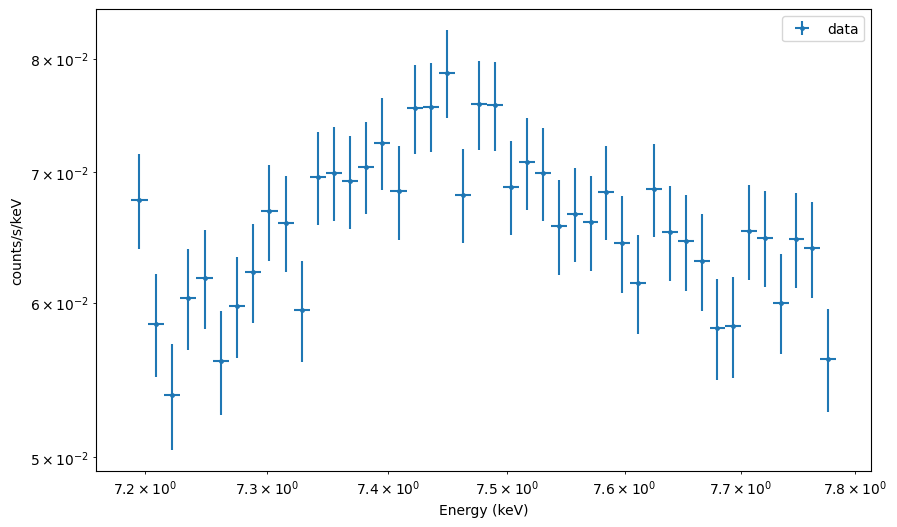

In [33]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)):
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Now I consider the Astro and Internal Background lines falling into the energy range +- 7 sigma. At the end I define arrays containing the position of the lines and the min and max values inside which they can fluctuate in the fit


In [34]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

if isinstance(vfileIBLine, list):
    ib_file = vfileIBLine[0]
else:
    ib_file = vfileIBLine

# Load IB lines
data = np.loadtxt(ib_file, skiprows=0)
IBenergy = data[:,0]
IBenergymin = data[:,2]
IBenergymax = data[:,5]
# IBenergymin = data[:,0]+0.02
# IBenergymax = data[:,0]+0.02
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/MarcoFitsMay/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]



ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl


IBn = len(IBLine)
An = len(ALine)
#
# For this model avoid Astro lines
#
IBALine = IBLine.copy()
IBALinemin = IBLinemin.copy()
IBALinemax = IBLinemax.copy()
IBAn = IBn
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine)
print(IBALinemin," ",IBALinemax)

Total lines  2  IB  2  A  0
[7.06845 7.48334]
[6.9 7.2]   [7.2 7.6]


FUNCTIONS TO SET LINES TO ZERO AND FIX THEM OR TO FREE THEM

In [35]:
# CLASS TO DEFINE A FUNCTION TO EVALUATE THE TS specified in fit GIVEN A xspec Model model
# with paramers value params, name (gaussian_3, powerlaw,...) params_name and target (norm, LineE,...) params_target

class MTmodel:
    def __init__(self, model, params_name, params_target, fit):
        self.model = model
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile fast setters for just the main value (index 0 of .values)
        self._param_fast_setters = [
            self._make_fast_setter(getattr(getattr(model, name), attr))
            for name, attr in zip(params_name, params_target)
        ]

        # Also keep full parameter objects for set_values_all
        self._param_objects = [
            getattr(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]

    def _make_fast_setter(self, param_obj):
        def setter(value, param_obj=param_obj):
            #param_obj.values[0] = value
            param_obj.values = value
        return setter

    #set value of parameters
    def set_values(self, params):
        for setter, value in zip(self._param_fast_setters, params):
            setter(float(value))  # direct, fast assignment

    #set value of parameters including upper/lower limits
    def set_values_all(self, params, lowers, uppers):
        for i, param in enumerate(self._param_objects):
            a = float(params[i])
            b = float(lowers[i])
            c = float(uppers[i])
            param.values = [a, 1e-2 * a, b, b, c, c]

    # evaluate TS given paramaters params
    def evaluate_folded(self, params):
        self.set_values(params)
        return self.fit.statistic

    # set a given params_name, params_target to keyfits, i.e. True/False. Relevant for fit with xSpec
    # Careful: my logic is True means is in the fit therefore corresponds to .frozen = False
    def set_frozen(self, keyfits):
        """
        Freeze or unfreeze parameters based on keyfits.
        keyfits[i] == True  → parameter is free (frozen = False)
        keyfits[i] == False → parameter is frozen (frozen = True)
        """
        if len(keyfits) != len(self.params_name):
            raise ValueError("keyfits must be the same length as params_name and params_target")

        for param, keep_free in zip(self._param_objects, keyfits):
            param.frozen = not keep_free  # Invert: True means not frozen

    # return the value of the parameters    
    def get_values(self):
        """Return current values (i.e., param.values[0]) as numpy array."""
        return np.array([param.values[0] for param in self._param_objects])

In [36]:
# Functions working on dictionary

# Given a dictionary model_dic,
# extract all entries as numpy arrays
def Extract_array_dic(model_dic):
    params = []
    lowers = []
    uppers = []
    keyfits = []
    params_name = []
    params_target = []
    for top_key, sub_models in model_dic.items():
        # Skip non-model entries like _structure
        if not isinstance(sub_models, dict):
            continue
        for sub_key, parameters in sub_models.items():
            for paramtarget, param_info in parameters.items():
                params.append(param_info["value"])
                lowers.append(param_info["lower"])
                uppers.append(param_info["upper"])
                keyfits.append(param_info["keyfit"])
                params_name.append(sub_key)     # second-level key (e.g., powerlaw_2)
                params_target.append(paramtarget)     # third-level key (e.g., PhoIndex)

    # Convert everything to NumPy arrays
    params = np.array(params)
    lowers = np.array(lowers)
    uppers = np.array(uppers)
    params_name = np.array(params_name)
    params_target = np.array(params_target)
    keyfits = np.array(keyfits)
    return (params,lowers,uppers,params_name,params_target,keyfits)

In [37]:
# Functions working on numpy arrays

# input arrays defining all the parameters of the model
# output: arrays of parameters entering in the fit (keyfits is True)
def paramfit(params, lowers, uppers , params_name, params_target, keyfits):
    # Create a mask for where keyfits is True
    mask = keyfits == True
    #print(keyfits)
    #print(mask)
    # Apply the mask
    params_out = params[mask]
    lowers_out = lowers[mask]
    uppers_out = uppers[mask]
    params_name_out = params_name[mask]
    params_target_out = params_target[mask]
    keyfits_out = keyfits[mask]
    bounds_out = np.column_stack((lowers_out, uppers_out))
    #print("Values:", params)
    #print("Lowers:", lowers)
    #print("Uppers:", uppers)
    #print("Keyfits:", keyfits)
    #print("Submodel keys:", params_name)
    #print("Param keys:", params_target)
    return (params_out, bounds_out, params_name_out, params_target_out, keyfits_out)

# Select element of params_name, params_target associated to params_name, target_key
# and for that change keyfits to keyfits_value
def change_keyfits(params_name, params_target, keyfits, name_key, target_key, keyfits_value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask) #True==1
    #print(idx[0]," ",name_key[idx[0]])
    keyfits[idx[0]] = keyfits_value

# For params associated to name_key, target_key change the value to key_value 
def change_param_value(params, params_name, params_target, name_key, target_key, value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    params[idx[0]] = value

# Return params associated to name_key, target_key
def return_param_value(params, params_name, params_target, name_key, target_key):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    return params[idx[0]]

# Print parameters
def printparam(params, lowers, uppers , params_name, params_target, keyfits):
    for i in range(0,len(params_name)):
        print(params_name[i]," ",params_target[i]," ", params[i]," ", lowers[i]," ", uppers[i]," ", keyfits[i])

Normalization factor (can be useful to define limits of the parameters)

In [38]:
# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
# For simplicity choose TM1
arf1test = fits.open(fileARFTM1)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, venergies[0], vrates[0])
normlDMhdata = Ratetest/Aefftest # counts/keV/s/cm2
print("normlDMhdata [counts/keV/s/cm2]",normlDMhdata)
# normlDMhdata2 is the correct normalization to set norm of DM gaussian line to a reasonable value! 
# It has the same units of norm of Gaussian
# See nAPEC_Alll.ipynb
normlDMhdata2 = normlDMhdata*np.sqrt(2*np.pi)*sigma # counts/s/cm2
print("normlDMhdata2 [counts/s/cm2]",normlDMhdata2)


normlDMhdata [counts/keV/s/cm2] 2.6716161570044217
normlDMhdata2 [counts/s/cm2] 0.40999724767053053


Create the dictionary of the model

In [39]:
#This is a model based on TBabsorption and APEC phenomenological models
def pdic(value, lower, upper, key):
    return {"value": value, "lower": lower, "upper": upper, "keyfit": key}



normline_start= normlDMhdata2*0.01 #*0.01
normline_lower = 1e-10
# normline_lower = 0
normline_upper = normlDMhdata2*100
sigmaDM = Eline*50/3e5 #1e-4
sigma_astrolines = 1e-4
#
#
#power law
startidx = 3 #1.4
upperidx = 6.0
loweridx = - 3.0
#
startpl = 0.1*normlDMhdata *np.pow(Eline,startidx)
# startpl = 0.05
upperpl = startpl*1000.0
lowerpl = 0.0

# %%
# model_dic = {
#     "gaussian": {
#         "gaussian": {
#             "norm": pdic(normline_start, normline_lower, normline_upper, False),
#             "LineE" : pdic(Eline, Eline, Eline, False),
#             "Sigma" : pdic(sigmaDM, sigmaDM, sigmaDM, False)
#         }
#     }
# }
# model_dic["_structure"] = f"gaussian"

# Keep only the PB model dictionary (this stays as is)
model_dic_pb = {
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(startidx, loweridx, upperidx, True),
            "norm" : pdic(startpl, lowerpl, upperpl, True)
        }
    },
    "gaussian": {}
}

# Add IB lines to gaussian dictionary
for i in range(len(IBALine)):
    if i == 0:
        g_key = "gaussian"
    else:
        g_key = f"gaussian_{i+2}"
    model_dic_pb["gaussian"][g_key] = {
        "norm": pdic(normline_start, normline_lower, normline_upper, True),
        # "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], True),
        "LineE": pdic(IBALine[i], IBALine[i]-0.03, IBALine[i]+0.03, True),
        "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False)
    }

print(model_dic_pb)


{'powerlaw': {'powerlaw': {'PhoIndex': {'value': 3, 'lower': -3.0, 'upper': 6.0, 'keyfit': True}, 'norm': {'value': np.float64(111.94412264442445), 'lower': 0.0, 'upper': np.float64(111944.12264442445), 'keyfit': True}}}, 'gaussian': {'gaussian': {'norm': {'value': np.float64(0.004099972476705306), 'lower': 1e-10, 'upper': np.float64(40.99972476705305), 'keyfit': True}, 'LineE': {'value': np.float64(7.06845), 'lower': np.float64(7.03845), 'upper': np.float64(7.098450000000001), 'keyfit': True}, 'Sigma': {'value': 0.0001, 'lower': 0.0001, 'upper': 0.0001, 'keyfit': False}}, 'gaussian_3': {'norm': {'value': np.float64(0.004099972476705306), 'lower': 1e-10, 'upper': np.float64(40.99972476705305), 'keyfit': True}, 'LineE': {'value': np.float64(7.48334), 'lower': np.float64(7.45334), 'upper': np.float64(7.51334), 'keyfit': True}, 'Sigma': {'value': 0.0001, 'lower': 0.0001, 'upper': 0.0001, 'keyfit': False}}}}


Define the model

In [40]:
AllModels.clear()

# Only create PB model
n_gauss = len(model_dic_pb["gaussian"])
print("n_gauss ", n_gauss)
model_string_pb = "powerlaw"
if n_gauss > 0:
    model_string_pb += " + " + " + ".join(["gaussian"] * n_gauss)
print("mpb model string:", model_string_pb)
model_dic_pb["_structure"] = model_string_pb

# Create the model (index 1, not 2)
m_pb = Model(model_string_pb, "mpb", 1)

print("MPB model components:", [name for name in dir(m_pb) if "gaussian" in name])

Xset.chatter = 0
Fit.statMethod = "cstat"
Fit.nIterations = 100000

# Extract info from PB model only
params_pb, lowers_pb, uppers_pb, params_name_pb, params_target_pb, keyfits_pb = Extract_array_dic(model_dic_pb)

# Create model wrapper for PB model
mymodel_pb = MTmodel(model=m_pb, params_name=params_name_pb, params_target=params_target_pb, fit=Fit)

# Set values and frozen parameters
mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
mymodel_pb.set_frozen(keyfits_pb)

# Print parameters
printparam(params_pb, lowers_pb, uppers_pb, params_name_pb, params_target_pb, keyfits_pb)

Fit.statMethod = "cstat"


n_gauss  2
mpb model string: powerlaw + gaussian + gaussian
MPB model components: ['gaussian', 'gaussian_3']
powerlaw   PhoIndex   3.0   -3.0   6.0   True
powerlaw   norm   111.94412264442445   0.0   111944.12264442445   True
gaussian   norm   0.004099972476705306   1e-10   40.99972476705305   True
gaussian   LineE   7.06845   7.03845   7.098450000000001   True
gaussian   Sigma   0.0001   0.0001   0.0001   False
gaussian_3   norm   0.004099972476705306   1e-10   40.99972476705305   True
gaussian_3   LineE   7.48334   7.45334   7.51334   True
gaussian_3   Sigma   0.0001   0.0001   0.0001   False


In [41]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 0


Parameters defined:
Model mpb:powerlaw<1> + gaussian<2> + gaussian<3> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            3.00000      +/-  0.0          
   2    1   powerlaw   norm                111.944      +/-  0.0          
   3    2   gaussian   LineE      keV      7.06845      +/-  0.0          
   4    2   gaussian   Sigma      keV      1.00000E-04  frozen
   5    2   gaussian   norm                4.09997E-03  +/-  0.0          
   6    3   gaussian   LineE      keV      7.48334      +/-  0.0          
   7    3   gaussian   Sigma      keV      1.00000E-04  frozen
   8    3   gaussian   norm                4.09997E-03  +/-  0.0          
________________________________________________________________________



In [42]:
# Pre-fit loop with different photon indices
TS = 1e6
for phoindex in np.arange(-3.0, 5, 1):
    change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "PhoIndex", phoindex)
    change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "norm", startpl)
    mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)

    Fit.method = "simplex"
    Fit.nIterations = 10000
    Fit.criticalDelta = 1e-3
    Fit.perform()

    Fit.method = "leven"
    Fit.nIterations = 10000
    Fit.criticalDelta = 1e-4
    Fit.perform()

    Fit.method = "migrad"
    Fit.nIterations = 10000
    Fit.criticalDelta = 1e-5
    Fit.perform()
    
    params_initial = mymodel_pb.get_values()
    params_name_initial = mymodel_pb.params_name
    params_target_initial = mymodel_pb.params_target
    
    if Fit.statistic < TS:
        TS = Fit.statistic
        phoindex_initial = return_param_value(params_initial, params_name_initial, params_target_initial, "powerlaw", "PhoIndex")
        norm_initial = return_param_value(params_initial, params_name_initial, params_target_initial, "powerlaw", "norm")

# Set best initial values
change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "PhoIndex", phoindex_initial)
change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "norm", norm_initial)
mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)

Perform Astrofit

In [43]:

Fit.method = "simplex"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-3
Fit.perform()

Fit.method = "leven"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-4
Fit.perform()

Fit.method = "migrad"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-5
Fit.perform()


TS_astro = Fit.statistic
nfit_astro = Fit.nVarPars
dof_astro = Fit.dof
pvalue_astro = Fit.nullhyp
params_astro_pb = mymodel_pb.get_values()
params_name_astro_pb = mymodel_pb.params_name
params_target_astro_pb = mymodel_pb.params_target

phoindex_bestfit = return_param_value(params_astro_pb, params_name_astro_pb, params_target_astro_pb, "powerlaw", "PhoIndex")

printparam(params_astro_pb, lowers_pb, uppers_pb , params_name_astro_pb, params_target_astro_pb, keyfits_pb)

print("Test Statistics ",TS_astro," testStatistics ",TS_astro," dof ",dof_astro," nVarPars ",nfit_astro)
print("pvalue ",pvalue_astro)

powerlaw   PhoIndex   -3.0   -3.0   6.0   True
powerlaw   norm   0.004966830892954022   0.0   111944.12264442445   True
gaussian   norm   0.3702656692642776   1e-10   40.99972476705305   True
gaussian   LineE   7.038450175281105   7.03845   7.098450000000001   True
gaussian   Sigma   0.0001   0.0001   0.0001   False
gaussian_3   norm   0.062369793845135746   1e-10   40.99972476705305   True
gaussian_3   LineE   7.466450925112741   7.45334   7.51334   True
gaussian_3   Sigma   0.0001   0.0001   0.0001   False
Test Statistics  46.8696054499876  testStatistics  46.8696054499876  dof  37  nVarPars  7
pvalue  0.09363167693


In [44]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpb:powerlaw<1> + gaussian<2> + gaussian<3> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            -3.00000     frozen
   2    1   powerlaw   norm                4.96683E-03  +/-  1.41421      
   3    2   gaussian   LineE      keV      7.03845      +/-  1.50564E-02  
   4    2   gaussian   Sigma      keV      1.00000E-04  +/-  2.59142E-02  
   5    2   gaussian   norm                0.370266     +/-  0.100000     
   6    3   gaussian   LineE      keV      7.46645      +/-  8.04763E-02  
   7    3   gaussian   Sigma      keV      1.00000E-04  +/-  2.59142E-02  
   8    3   gaussian   norm                6.23698E-02  +/-  0.100000     
________________________________________________________________________



Plot command list is now empty


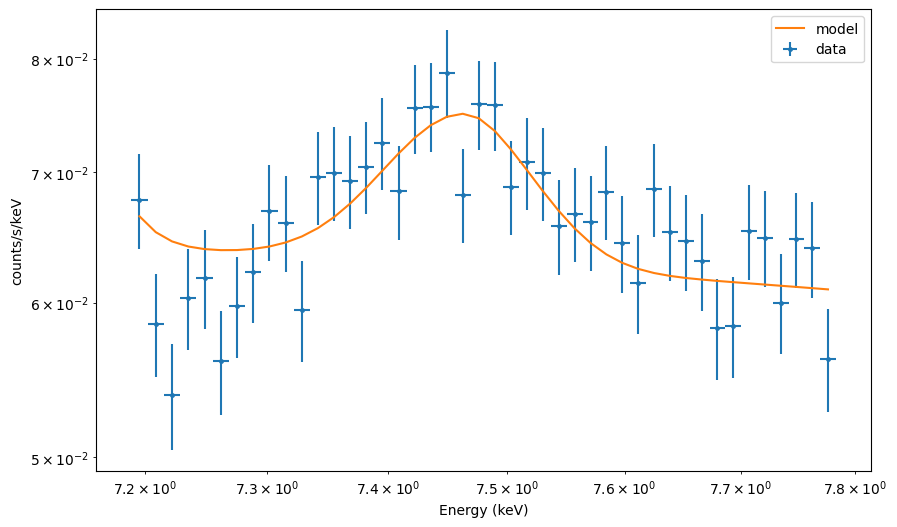

In [45]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

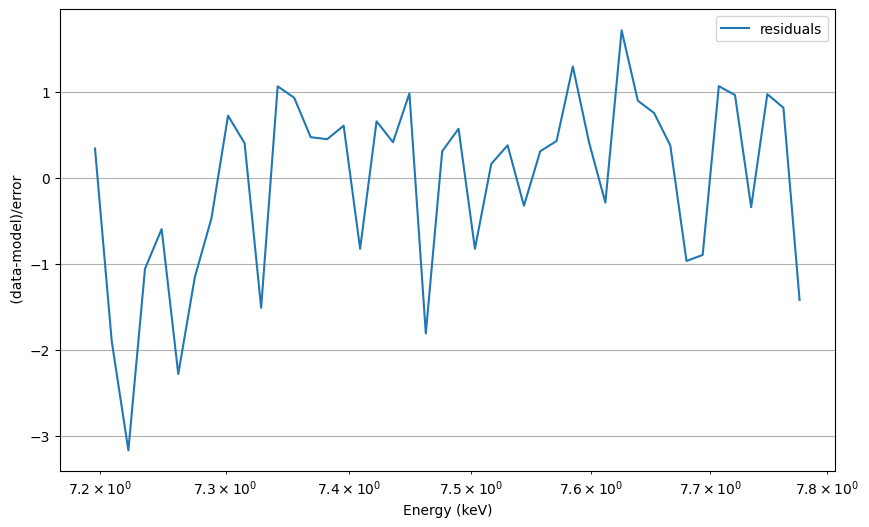

In [46]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  3
Identified components: ['DM Gaussian (inactive)', 'Component 2', 'Powerlaw', 'IB Line 7.038 keV']

Model components breakdown:
  DM Gaussian (inactive): max value = 6.39e-02, integral ≈ 3.63e-02
  Component 2: max value = 2.50e-03, integral ≈ 5.00e-05
  Powerlaw: max value = 1.23e-02, integral ≈ 1.89e-03


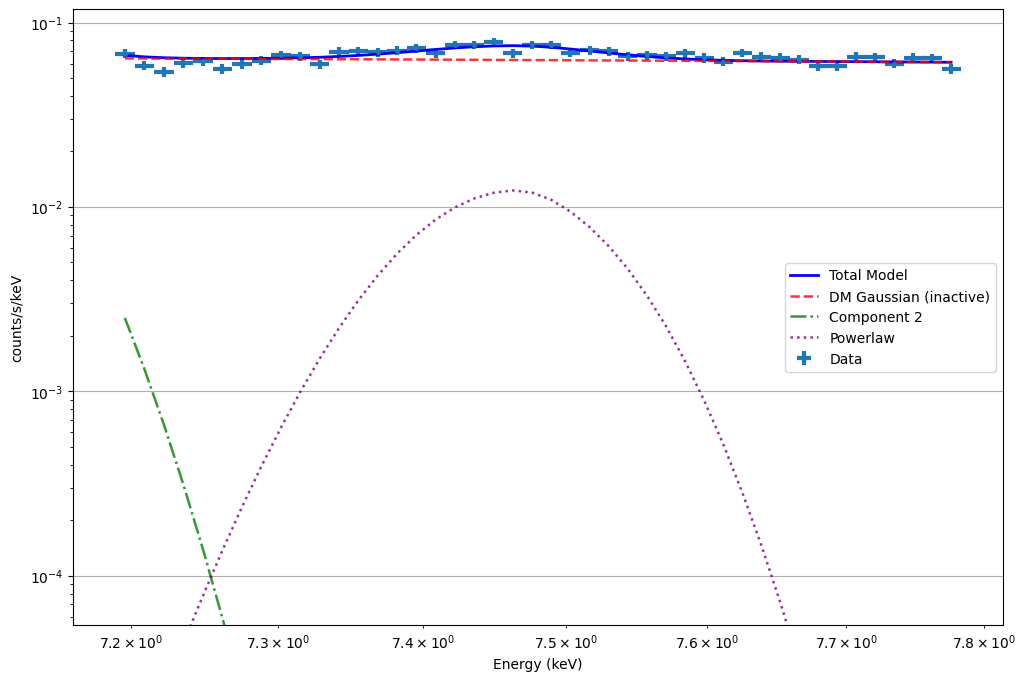

In [47]:
# Improved component identification based on debug output
def identify_components():
    """Identify model components based on XSPEC structure and parameter values."""
    component_names = []
    
    # Based on your model structure, XSPEC combines additive components from both models
    # MW model: TBabs * (apec + gaussian) -> contributes apec and gaussian (if norm > 0)
    # PB model: powerlaw + gaussian(s) -> contributes powerlaw and IB gaussians
    
    try:
        # Component 1: Always seems to be zero in your case (might be DM gaussian with norm=0)
        component_names.append('DM Gaussian (inactive)')
        
        # Component 2: Check if it's APEC from MW model
        try:
            apec_norm = m_mw.apec.norm.values[0]
            if apec_norm > 1e-15:
                component_names.append('APEC')
            else:
                component_names.append('Component 2')
        except:
            component_names.append('Component 2')
        
        # Component 3: Check if it's powerlaw from PB model
        try:
            pl_norm = AllModels(1, "mpb").powerlaw.norm.values[0]
            if pl_norm > 1e-15:
                component_names.append('Powerlaw')
            else:
                component_names.append('Component 3')
        except:
            component_names.append('Component 3')
        
        # Component 4+: IB Gaussian lines from PB model
        try:
            mpb_model = AllModels(1, "mpb")
            gaussian_idx = 0
            
            # Check main gaussian
            if hasattr(mpb_model, 'gaussian'):
                gauss_norm = mpb_model.gaussian.norm.values[0]
                if gauss_norm > 1e-15:
                    line_energy = mpb_model.gaussian.LineE.values[0]
                    component_names.append(f'IB Line {line_energy:.3f} keV')
                    gaussian_idx += 1
            
            # Check additional gaussians (gaussian_2, gaussian_3, etc.)
            for i in range(2, 10):
                gauss_name = f'gaussian_{i}'
                if hasattr(mpb_model, gauss_name):
                    gauss_obj = getattr(mpb_model, gauss_name)
                    gauss_norm = gauss_obj.norm.values[0]
                    if gauss_norm > 1e-15:
                        line_energy = gauss_obj.LineE.values[0]
                        if len(component_names) <= 3 + gaussian_idx:
                            component_names.append(f'IB Line {line_energy:.3f} keV')
                        gaussian_idx += 1
                else:
                    break
                    
        except Exception as e:
            print(f"Error identifying IB lines: {e}")
            # Fill remaining with generic names
            while len(component_names) < 4:
                component_names.append(f'Component {len(component_names)+1}')
    
    except Exception as e:
        print(f"Error in component identification: {e}")
        # Fallback to generic names
        component_names = [f'Component {i+1}' for i in range(4)]
    
    return component_names

# Updated plotting code with proper component identification
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

# Get proper component names
component_names = identify_components()
print("Identified components:", component_names)

# Ensure we have the right number of components
while len(component_names) < nAddComps:
    component_names.append(f'Component {len(component_names)+1}')

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp_comp = i + 1
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp_comp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(12,8))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='Data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='Total Model',color='blue', linewidth=2)

# Define colors and line styles for components
colors = ['red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'orange']
linestyles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', '--', '-.']

# Plot each component with its proper label
for i in range(nAddComps):
    color = colors[i % len(colors)]
    linestyle = linestyles[i % len(linestyles)]
    
    # Use the component name we identified
    label = component_names[i] if i < len(component_names) else f'Component {i+1}'
    
    # Skip plotting components with zero contribution
    if np.max(modelcomp[i]) > 1e-10:  # Only plot if component has significant contribution
        ax.plot(energiesTMi, modelcomp[i][:], 
                label=label, 
                linestyle=linestyle, 
                color=color,
                linewidth=1.8,
                alpha=0.8)

ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.001,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend(loc='best')

# Print component information
print("\nModel components breakdown:")
for i in range(nAddComps):
    name = component_names[i] if i < len(component_names) else f'Component {i+1}'
    max_val = np.max(modelcomp[i])
    integral = np.trapezoid(modelcomp[i], energiesTMi)
    print(f"  {name}: max value = {max_val:.2e}, integral ≈ {integral:.2e}")

NOW FIT ASTRO + DM

In [48]:
'''
# NOW FIT ASTRO + DM
# Change DM norm and T/F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", True)
change_param_value(params, params_name, params_target, "gaussian", "norm", normline_start)
#
# printparam(params_astro, lowers, uppers , params_name_fit, params_target_fit, keyfits_fit)
print("****************")
# set the other parameters to their best-fit value of previous fit
for val, name, attr in zip(params_astro, params_name_astro, params_target_astro):
    # Skip updating the DM gaussian norm - we want to keep normline_start
    if name == "gaussian" and attr == "norm":
        continue
    change_param_value(params, params_name, params_target, name, attr, val)
# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)
#
# Select the parameters to Fit. You can check that DM is present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)


Xset.chatter = 10
AllModels.show()
Xset.chatter = 1
'''

'\n# NOW FIT ASTRO + DM\n# Change DM norm and T/F\nchange_keyfits(params_name, params_target, keyfits, "gaussian", "norm", True)\nchange_param_value(params, params_name, params_target, "gaussian", "norm", normline_start)\n#\n# printparam(params_astro, lowers, uppers , params_name_fit, params_target_fit, keyfits_fit)\nprint("****************")\n# set the other parameters to their best-fit value of previous fit\nfor val, name, attr in zip(params_astro, params_name_astro, params_target_astro):\n    # Skip updating the DM gaussian norm - we want to keep normline_start\n    if name == "gaussian" and attr == "norm":\n        continue\n    change_param_value(params, params_name, params_target, name, attr, val)\n# since you have changed norm and key(True/False), update XSpec\nmymodel_mw.set_values_all(params, lowers, uppers)\nmymodel_mw.set_frozen(keyfits)\n#\n# Select the parameters to Fit. You can check that DM is present\nparams_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_f

In [49]:
'''
Fit.method = "simplex"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-3
Fit.perform()

Fit.method = "leven"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-4
Fit.perform()

Fit.method = "migrad"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-5
Fit.perform()

print("**************** **************** ****************")
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1



TS_DM = Fit.statistic
nfit_dm = Fit.nVarPars
dof_DM = Fit.dof
pvalue_DM = Fit.nullhyp
params_DM = mymodel_mw.get_values()


DMbf = return_param_value(params_DM , params_name_fit, params_target_fit, "gaussian", "norm")
print("DM bf ",DMbf)
print("DeltaTS ",TS_astro-TS_DM)

print("Test Statistics DM ",TS_DM," dof ",dof_DM," nVarPars ",nfit_dm)
print("pvalue ",pvalue_DM)
'''

'\nFit.method = "simplex"\nFit.nIterations = 10000\nFit.criticalDelta = 1e-3\nFit.perform()\n\nFit.method = "leven"\nFit.nIterations = 10000\nFit.criticalDelta = 1e-4\nFit.perform()\n\nFit.method = "migrad"\nFit.nIterations = 10000\nFit.criticalDelta = 1e-5\nFit.perform()\n\nprint("**************** **************** ****************")\nXset.chatter = 10\nAllModels.show()\nXset.chatter = 1\n\n\n\nTS_DM = Fit.statistic\nnfit_dm = Fit.nVarPars\ndof_DM = Fit.dof\npvalue_DM = Fit.nullhyp\nparams_DM = mymodel_mw.get_values()\n\n\nDMbf = return_param_value(params_DM , params_name_fit, params_target_fit, "gaussian", "norm")\nprint("DM bf ",DMbf)\nprint("DeltaTS ",TS_astro-TS_DM)\n\nprint("Test Statistics DM ",TS_DM," dof ",dof_DM," nVarPars ",nfit_dm)\nprint("pvalue ",pvalue_DM)\n'

In [50]:
'''
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

'''

'\nPlot.commands = ()\nPlot.xAxis = "keV"\nPlot("data")\n#ax.clear()\n\nfig, ax = plt.subplots(figsize=(10,6))\nfor plot_grp in range(1,len(vfilespectrum)+1):\n    energies = np.asarray(Plot.x(plot_grp))\n    edeltas = np.asarray(Plot.xErr(plot_grp))\n    rates = np.asarray(Plot.y(plot_grp))\n    errors = np.asarray(Plot.yErr(plot_grp))\n    foldedmodel = np.asarray(Plot.model(plot_grp))\n    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt=\'.\',markersize=\'5\',label=\'data\')\n    ax.plot(energies, foldedmodel,label=\'model\')\n\n#ax.axhline(y=10)\nax.set_xlabel(\'Energy (keV)\')\nax.set_ylabel(r\'counts/s/keV\')\nax.set_xscale("log")\nax.set_yscale("log")\n#ax.set_ylim((0.001,0.1))\nax.grid()\nax.legend()\n\n'

In [51]:
'''# Improved component identification based on debug output
def identify_components():
    """Identify model components based on XSPEC structure and parameter values."""
    component_names = []
    
    try:
        # Component 1: Check if DM gaussian is active (FIXED LOGIC)
        try:
            dm_norm = m_mw.gaussian.norm.values[0]
            print(f"DEBUG: DM norm = {dm_norm:.2e}")  # Debug print
            if dm_norm > 1e-15:
                component_names.append(f'DM Gaussian (norm={dm_norm:.2e})')
            else:
                component_names.append('DM Gaussian (inactive)')
        except Exception as e:
            print(f"DEBUG: Error accessing DM norm: {e}")
            component_names.append('DM Gaussian (inactive)')
        
        # Component 2: Check if it's APEC from MW model
        try:
            apec_norm = m_mw.apec.norm.values[0]
            if apec_norm > 1e-15:
                component_names.append('APEC')
            else:
                component_names.append('Component 2')
        except:
            component_names.append('Component 2')
        
        # Component 3: Check if it's powerlaw from PB model
        try:
            pl_norm = AllModels(1, "mpb").powerlaw.norm.values[0]
            if pl_norm > 1e-15:
                component_names.append('Powerlaw')
            else:
                component_names.append('Component 3')
        except:
            component_names.append('Component 3')
        
        # Component 4+: IB Gaussian lines from PB model
        try:
            mpb_model = AllModels(1, "mpb")
            gaussian_idx = 0
            
            # Check main gaussian
            if hasattr(mpb_model, 'gaussian'):
                gauss_norm = mpb_model.gaussian.norm.values[0]
                if gauss_norm > 1e-15:
                    line_energy = mpb_model.gaussian.LineE.values[0]
                    component_names.append(f'IB Line {line_energy:.3f} keV')
                    gaussian_idx += 1
            
            # Check additional gaussians (gaussian_2, gaussian_3, etc.)
            for i in range(2, 10):
                gauss_name = f'gaussian_{i}'
                if hasattr(mpb_model, gauss_name):
                    gauss_obj = getattr(mpb_model, gauss_name)
                    gauss_norm = gauss_obj.norm.values[0]
                    if gauss_norm > 1e-15:
                        line_energy = gauss_obj.LineE.values[0]
                        if len(component_names) <= 3 + gaussian_idx:
                            component_names.append(f'IB Line {line_energy:.3f} keV')
                        gaussian_idx += 1
                else:
                    break
                    
        except Exception as e:
            print(f"Error identifying IB lines: {e}")
            # Fill remaining with generic names
            while len(component_names) < nAddComps:
                component_names.append(f'Component {len(component_names)+1}')
    
    except Exception as e:
        print(f"Error in component identification: {e}")
        # Fallback to generic names
        component_names = [f'Component {i+1}' for i in range(nAddComps)]
    
    return component_names

# Updated plotting code with proper component identification for DM fit
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

# Get proper component names (NOW WITH DM ACTIVE)
component_names = identify_components()
print("Identified components:", component_names)

# Ensure we have the right number of components
while len(component_names) < nAddComps:
    component_names.append(f'Component {len(component_names)+1}')

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp_comp = i + 1
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp_comp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(12,8))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='Data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='Total Model',color='blue', linewidth=2)

# Define colors and line styles for components
colors = ['red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'orange']
linestyles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', '--', '-.']

# Plot each component with its proper label
for i in range(nAddComps):
    color = colors[i % len(colors)]
    linestyle = linestyles[i % len(linestyles)]
    
    # Use the component name we identified
    label = component_names[i] if i < len(component_names) else f'Component {i+1}'
    
    # Plot all components (including active DM component)
    if np.max(modelcomp[i]) > 1e-15:  # Only plot if component has significant contribution
        ax.plot(energiesTMi, modelcomp[i][:], 
                label=label, 
                linestyle=linestyle, 
                color=color,
                linewidth=1.8,
                alpha=0.8)
    else:
        print(f"Skipping {label} (max = {np.max(modelcomp[i]):.2e})")

ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.1,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend(loc='best')

# Print component information
print("\nModel components breakdown (DM FIT):")
for i in range(nAddComps):
    name = component_names[i] if i < len(component_names) else f'Component {i+1}'
    max_val = np.max(modelcomp[i])
    integral = np.trapezoid(modelcomp[i], energiesTMi)
    print(f"  {name}: max value = {max_val:.2e}, integral ≈ {integral:.2e}")

# Print DM component info
try:
    dm_norm = m_mw.gaussian.norm.values[0]
    dm_energy = m_mw.gaussian.LineE.values[0]
    dm_sigma = m_mw.gaussian.Sigma.values[0]
    print(f"\nDM Gaussian parameters:")
    print(f"  Normalization: {dm_norm:.2e}")
    print(f"  Line Energy: {dm_energy:.3f} keV")
    print(f"  Sigma: {dm_sigma:.3f} keV")
except Exception as e:
    print(f"Error getting DM parameters: {e}")
    '''

'# Improved component identification based on debug output\ndef identify_components():\n    """Identify model components based on XSPEC structure and parameter values."""\n    component_names = []\n    \n    try:\n        # Component 1: Check if DM gaussian is active (FIXED LOGIC)\n        try:\n            dm_norm = m_mw.gaussian.norm.values[0]\n            print(f"DEBUG: DM norm = {dm_norm:.2e}")  # Debug print\n            if dm_norm > 1e-15:\n                component_names.append(f\'DM Gaussian (norm={dm_norm:.2e})\')\n            else:\n                component_names.append(\'DM Gaussian (inactive)\')\n        except Exception as e:\n            print(f"DEBUG: Error accessing DM norm: {e}")\n            component_names.append(\'DM Gaussian (inactive)\')\n        \n        # Component 2: Check if it\'s APEC from MW model\n        try:\n            apec_norm = m_mw.apec.norm.values[0]\n            if apec_norm > 1e-15:\n                component_names.append(\'APEC\')\n           

In [52]:
'''# Change DM  T/F setting to F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
#
# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)
#

m_mw.gaussian.norm = 0.1
pparams_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)



Fit.method = "simplex"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-3
Fit.perform()

Fit.method = "leven"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-4
Fit.perform()

Fit.method = "migrad"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-5
Fit.perform()


TS_Bound = Fit.statistic
nfit_dm = Fit.nVarPars
dof_DM = Fit.dof
pvalue_DM = Fit.nullhyp
params_DM = mymodel_mw.get_values()


# print("DeltaTS ",TS_astro-TS_DM)

print("Test Statistics DM ",TS_Bound," dof ",dof_DM," nVarPars ",nfit_dm)
print("Delta TS ",TS_Bound-TS_DM)
print("pvalue ",pvalue_DM)'''

'# Change DM  T/F setting to F\nchange_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)\n#\n# since you have changed norm and key(True/False), update XSpec\nmymodel_mw.set_values_all(params, lowers, uppers)\nmymodel_mw.set_frozen(keyfits)\n#\n\nm_mw.gaussian.norm = 0.1\npparams_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)\n\n\n\nFit.method = "simplex"\nFit.nIterations = 10000\nFit.criticalDelta = 1e-3\nFit.perform()\n\nFit.method = "leven"\nFit.nIterations = 10000\nFit.criticalDelta = 1e-4\nFit.perform()\n\nFit.method = "migrad"\nFit.nIterations = 10000\nFit.criticalDelta = 1e-5\nFit.perform()\n\n\nTS_Bound = Fit.statistic\nnfit_dm = Fit.nVarPars\ndof_DM = Fit.dof\npvalue_DM = Fit.nullhyp\nparams_DM = mymodel_mw.get_values()\n\n\n# print("DeltaTS ",TS_astro-TS_DM)\n\nprint("Test Statistics DM ",TS_Bound," dof ",dof_DM," nVarPars ",nfit_dm)\nprint("Delta TS ",TS_Bound-TS_DM

In [53]:
'''Xset.chatter = 10
AllModels.show()
Xset.closeLog()
Xset.chatter = 1
'''


'Xset.chatter = 10\nAllModels.show()\nXset.closeLog()\nXset.chatter = 1\n'

In [54]:
'''# Improved component identification based on debug output
def identify_components():
    """Identify model components based on XSPEC structure and parameter values."""
    component_names = []
    
    try:
        # Component 1: Check if DM gaussian is active (FIXED LOGIC)
        try:
            dm_norm = m_mw.gaussian.norm.values[0]
            print(f"DEBUG: DM norm = {dm_norm:.2e}")  # Debug print
            if dm_norm > 1e-15:
                component_names.append(f'DM Gaussian (norm={dm_norm:.2e})')
            else:
                component_names.append('DM Gaussian (inactive)')
        except Exception as e:
            print(f"DEBUG: Error accessing DM norm: {e}")
            component_names.append('DM Gaussian (inactive)')
        
        # Component 2: Check if it's APEC from MW model
        try:
            apec_norm = m_mw.apec.norm.values[0]
            if apec_norm > 1e-15:
                component_names.append('APEC')
            else:
                component_names.append('Component 2')
        except:
            component_names.append('Component 2')
        
        # Component 3: Check if it's powerlaw from PB model
        try:
            pl_norm = AllModels(1, "mpb").powerlaw.norm.values[0]
            if pl_norm > 1e-15:
                component_names.append('Powerlaw')
            else:
                component_names.append('Component 3')
        except:
            component_names.append('Component 3')
        
        # Component 4+: IB Gaussian lines from PB model
        try:
            mpb_model = AllModels(1, "mpb")
            gaussian_idx = 0
            
            # Check main gaussian
            if hasattr(mpb_model, 'gaussian'):
                gauss_norm = mpb_model.gaussian.norm.values[0]
                if gauss_norm > 1e-15:
                    line_energy = mpb_model.gaussian.LineE.values[0]
                    component_names.append(f'IB Line {line_energy:.3f} keV')
                    gaussian_idx += 1
            
            # Check additional gaussians (gaussian_2, gaussian_3, etc.)
            for i in range(2, 10):
                gauss_name = f'gaussian_{i}'
                if hasattr(mpb_model, gauss_name):
                    gauss_obj = getattr(mpb_model, gauss_name)
                    gauss_norm = gauss_obj.norm.values[0]
                    if gauss_norm > 1e-15:
                        line_energy = gauss_obj.LineE.values[0]
                        if len(component_names) <= 3 + gaussian_idx:
                            component_names.append(f'IB Line {line_energy:.3f} keV')
                        gaussian_idx += 1
                else:
                    break
                    
        except Exception as e:
            print(f"Error identifying IB lines: {e}")
            # Fill remaining with generic names
            while len(component_names) < nAddComps:
                component_names.append(f'Component {len(component_names)+1}')
    
    except Exception as e:
        print(f"Error in component identification: {e}")
        # Fallback to generic names
        component_names = [f'Component {i+1}' for i in range(nAddComps)]
    
    return component_names

# Updated plotting code with proper component identification for DM fit
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

# Get proper component names (NOW WITH DM ACTIVE)
component_names = identify_components()
print("Identified components:", component_names)

# Ensure we have the right number of components
while len(component_names) < nAddComps:
    component_names.append(f'Component {len(component_names)+1}')

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp_comp = i + 1
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp_comp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(12,8))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='Data',linewidth=3.0)
# ax.plot(energiesTMi, foldedmodel,label='Total Model',color='blue', linewidth=2)

# Define colors and line styles for components
colors = ['red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'orange']
linestyles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', '--', '-.']

# Plot each component with its proper label
for i in range(nAddComps):
    color = colors[i % len(colors)]
    linestyle = linestyles[i % len(linestyles)]
    
    # Use the component name we identified
    label = component_names[i] if i < len(component_names) else f'Component {i+1}'
    
    # Plot all components (including active DM component)
    if np.max(modelcomp[i]) > 1e-15:  # Only plot if component has significant contribution
        ax.plot(energiesTMi, modelcomp[i][:], 
                label=label, 
                linestyle=linestyle, 
                color=color,
                linewidth=1.8,
                alpha=0.8)
    else:
        print(f"Skipping {label} (max = {np.max(modelcomp[i]):.2e})")

ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.00001,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend(loc='best')

# Print component information
print("\nModel components breakdown (DM FIT):")
for i in range(nAddComps):
    name = component_names[i] if i < len(component_names) else f'Component {i+1}'
    max_val = np.max(modelcomp[i])
    integral = np.trapezoid(modelcomp[i], energiesTMi)
    print(f"  {name}: max value = {max_val:.2e}, integral ≈ {integral:.2e}")

# Print DM component info
try:
    dm_norm = m_mw.gaussian.norm.values[0]
    dm_energy = m_mw.gaussian.LineE.values[0]
    dm_sigma = m_mw.gaussian.Sigma.values[0]
    print(f"\nDM Gaussian parameters:")
    print(f"  Normalization: {dm_norm:.2e}")
    print(f"  Line Energy: {dm_energy:.3f} keV")
    print(f"  Sigma: {dm_sigma:.3f} keV")
except Exception as e:
    print(f"Error getting DM parameters: {e}")
    '''

'# Improved component identification based on debug output\ndef identify_components():\n    """Identify model components based on XSPEC structure and parameter values."""\n    component_names = []\n    \n    try:\n        # Component 1: Check if DM gaussian is active (FIXED LOGIC)\n        try:\n            dm_norm = m_mw.gaussian.norm.values[0]\n            print(f"DEBUG: DM norm = {dm_norm:.2e}")  # Debug print\n            if dm_norm > 1e-15:\n                component_names.append(f\'DM Gaussian (norm={dm_norm:.2e})\')\n            else:\n                component_names.append(\'DM Gaussian (inactive)\')\n        except Exception as e:\n            print(f"DEBUG: Error accessing DM norm: {e}")\n            component_names.append(\'DM Gaussian (inactive)\')\n        \n        # Component 2: Check if it\'s APEC from MW model\n        try:\n            apec_norm = m_mw.apec.norm.values[0]\n            if apec_norm > 1e-15:\n                component_names.append(\'APEC\')\n           